# 🕰️ ALL ABOUT DURATIONS AND SEGMENTATION IN THE MANUAL SEGMENTATION DATA 🕰️

Feel free to click on the source to see how the code works or you can also simply scroll through to see the plots if you are in a rush!!!

**Let's start by importing our libraries!**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import friends_pack

**Now we load the tsv data for our saliency peak data**

In [2]:
df= pd.read_csv("../output/manual_segmentation_all.tsv", sep='\t')

In [9]:
df

,episode,scene,segment,onset,offset,duration,ONbond_location,ONbond_charact_entry,ONbond_charact_leave,ONbond_time_jump,...,OFFbond_end,loc_apt1_Mon_Rach,loc_apt2_Chan_Joey,loc_apt3_Ross,loc_apt4_Pheob_Rach,loc_coffeeshop,loc_outside,loc_other,global_segment,episode_full
0,s1e01a,1,1,0.0,10.0,10.0,False,False,False,False,...,False,False,False,False,False,False,False,False,1,s1e01
1,s1e01a,2,2,10.0,18.0,8.0,False,False,False,False,...,False,False,False,False,False,False,True,False,2,s1e01
2,s1e01a,3,3,18.0,55.0,37.0,False,False,False,False,...,False,False,False,False,False,True,False,False,3,s1e01
3,s1e01a,3,4,55.0,101.0,46.0,False,False,False,True,...,False,False,False,False,False,True,False,False,4,s1e01
4,s1e01a,3,5,101.0,214.0,113.0,False,True,False,True,...,False,False,False,False,False,True,False,False,5,s1e01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6218,s6e24d,7,11,524.0,534.0,10.0,False,True,False,False,...,False,True,False,False,False,False,False,False,6219,s6e24
6219,s6e24d,7,12,534.0,651.0,117.0,False,False,True,False,...,False,True,False,False,False,False,False,False,6220,s6e24
6220,s6e24d,7,13,651.0,657.0,6.0,False,False,False,False,...,False,True,False,False,False,False,False,False,6221,s6e24
6221,s6e24d,7,14,657.0,686.0,29.0,False,True,False,False,...,False,True,False,False,False,False,False,False,6222,s6e24


# NUMBER OF SEGMENTS 🧩 IN EPISODES

Since the episodes all have roughly the same length, it is interesting to see that some episodes have a lot more segments than others

/tmp/ipykernel_8824/3503467710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=num_segments, x="episode_full", y="num_segments", palette="viridis")


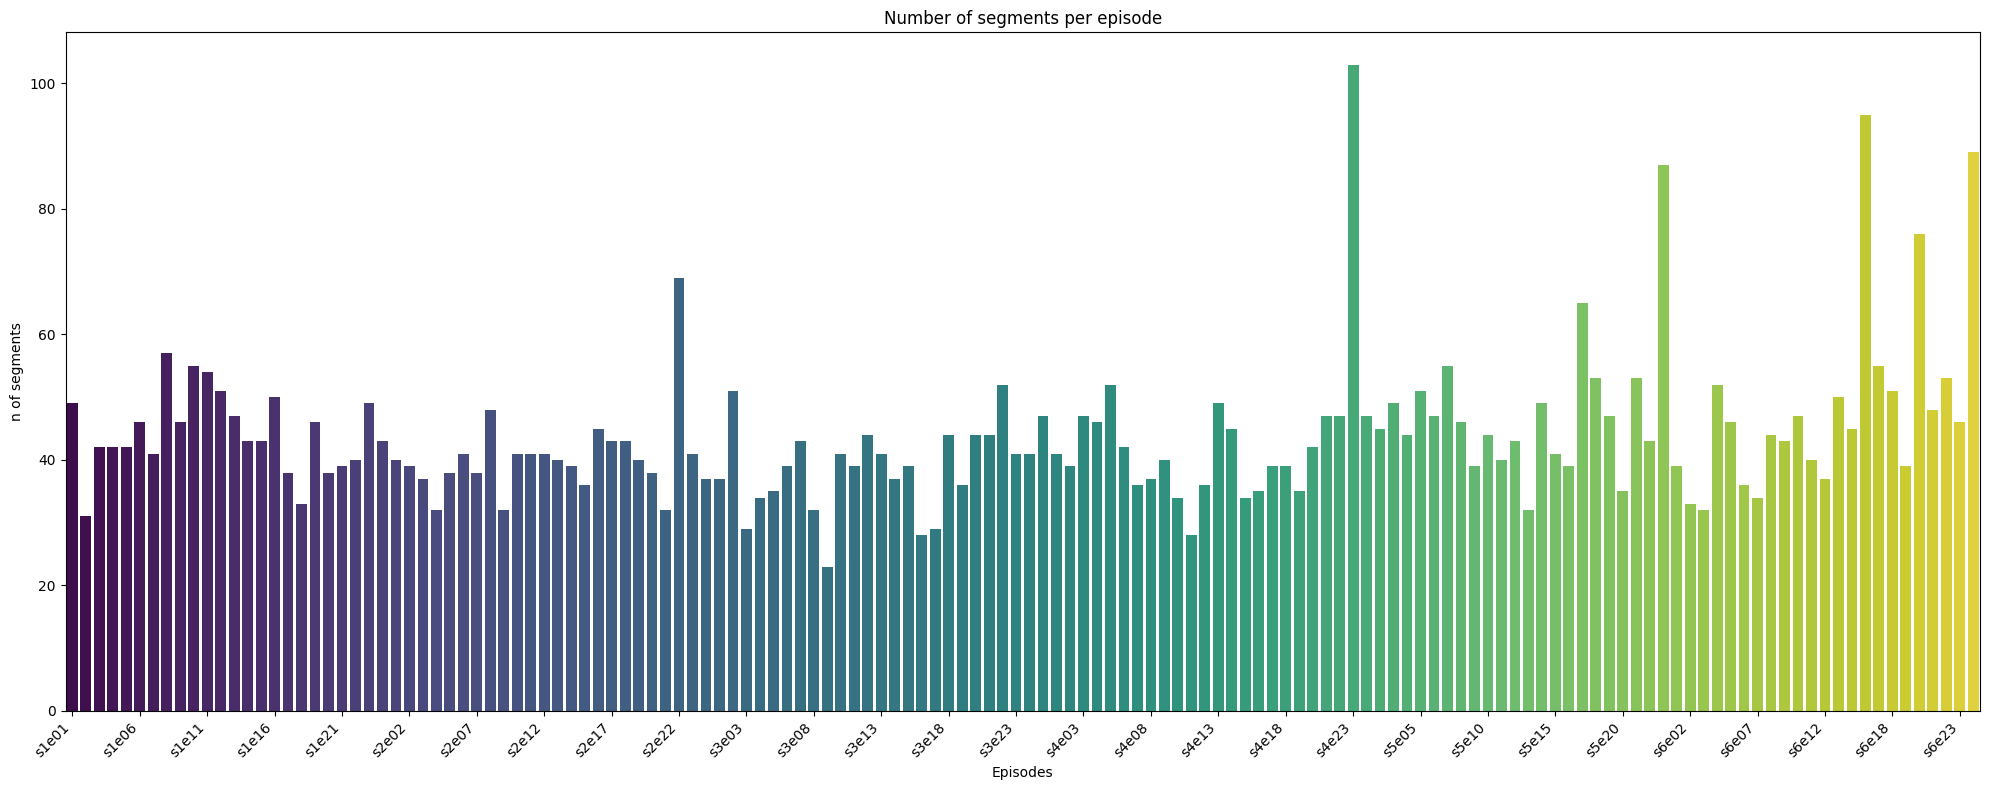

In [3]:
num_segments = df.groupby("episode_full").size().reset_index(name='num_segments')
plt.figure(figsize=(20, 8))
ax = sns.barplot(data=num_segments, x="episode_full", y="num_segments", palette="viridis")
ax.set_xticks(ax.get_xticks()[::5])  # show every 5th label
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.title("Number of segments per episode")
plt.ylabel("n of segments")
plt.xlabel("Episodes")
plt.tight_layout()
plt.show()

# AVERAGE DURATION 🕰️ OF SEGMENTS PER EPISODES

AS we can see here the episodes with more segements, have an average segments that are shorter and episodes with less segments have segments that run longer!

/tmp/ipykernel_8824/1605070300.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mean_duration, x="episode_full", y="duration", palette="viridis")


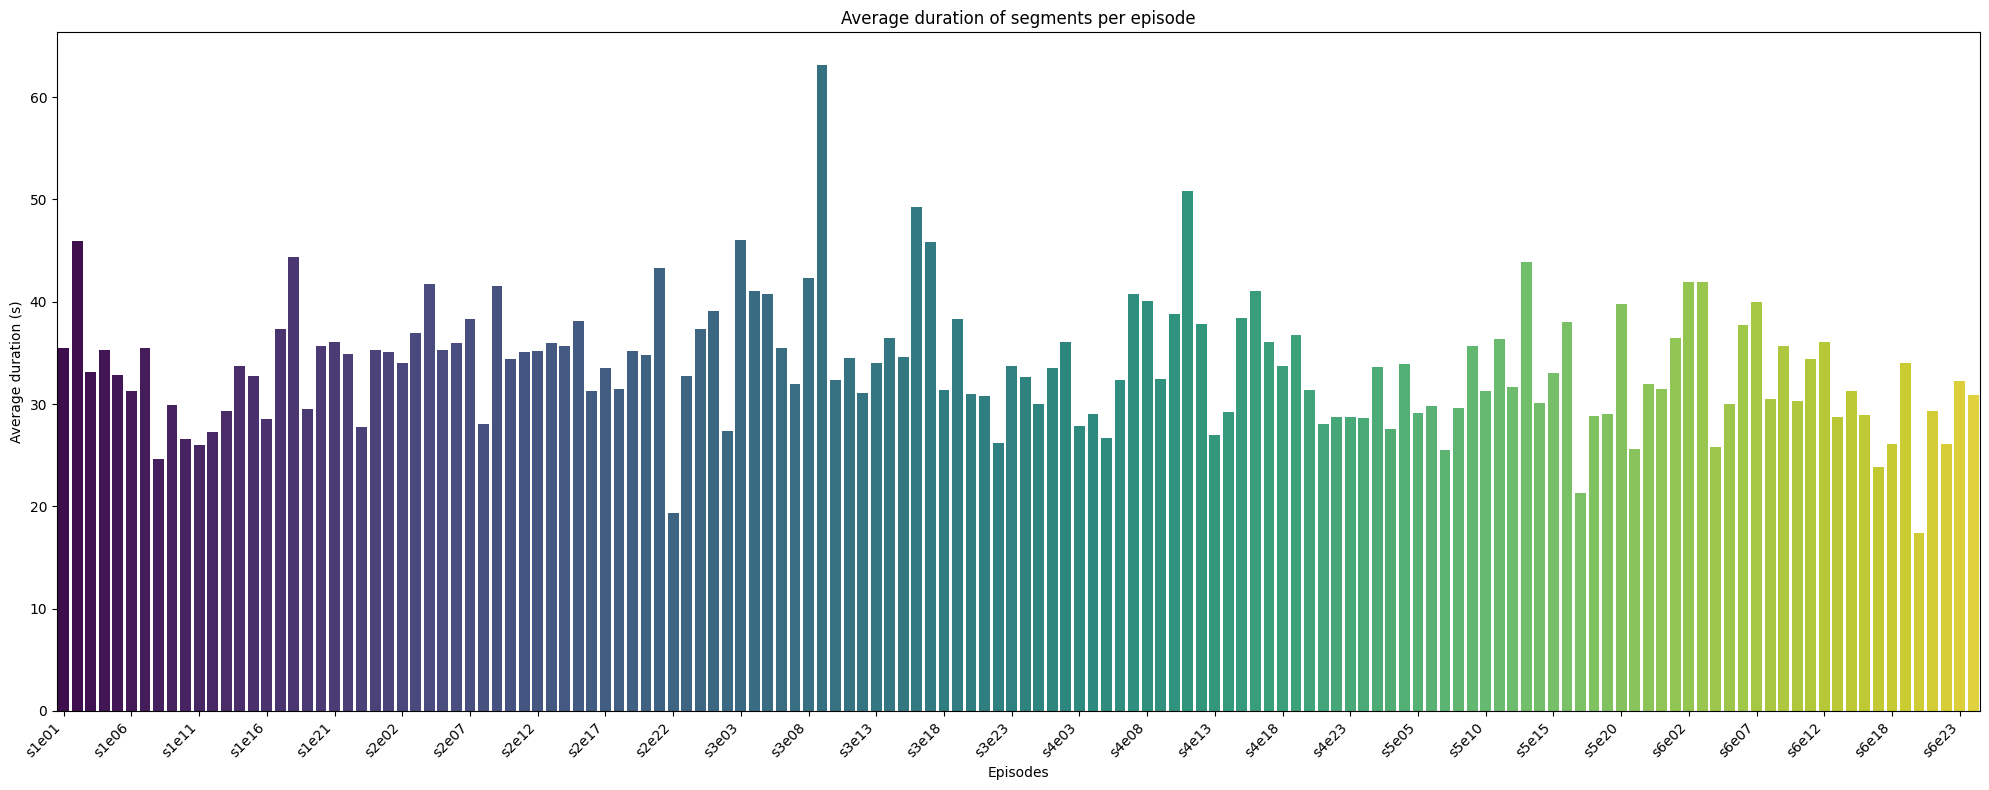

In [4]:
#average duration of scenes per episode for manual segementation
mean_duration = df.groupby("episode_full")["duration"].mean().reset_index()


plt.figure(figsize=(20, 8))
ax = sns.barplot(data=mean_duration, x="episode_full", y="duration", palette="viridis")
ax.set_xticks(ax.get_xticks()[::5])  # show every 5th label
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.title("Average duration of segments per episode")
plt.ylabel("Average duration (s)")
plt.xlabel("Episodes")
plt.tight_layout()
plt.show()


# NUMBER OF SEGMENTS 🧩 PER LOCATION 📍🧛‍♂️

I use a function from my very own package (friends_pack) to count the number of segments in a location, feel free to go on my github (click on the github logo at the top of the page) to see how it works.

We see that a lot of these segements are in Monica and Rachel<s apartement and in "other" locations.

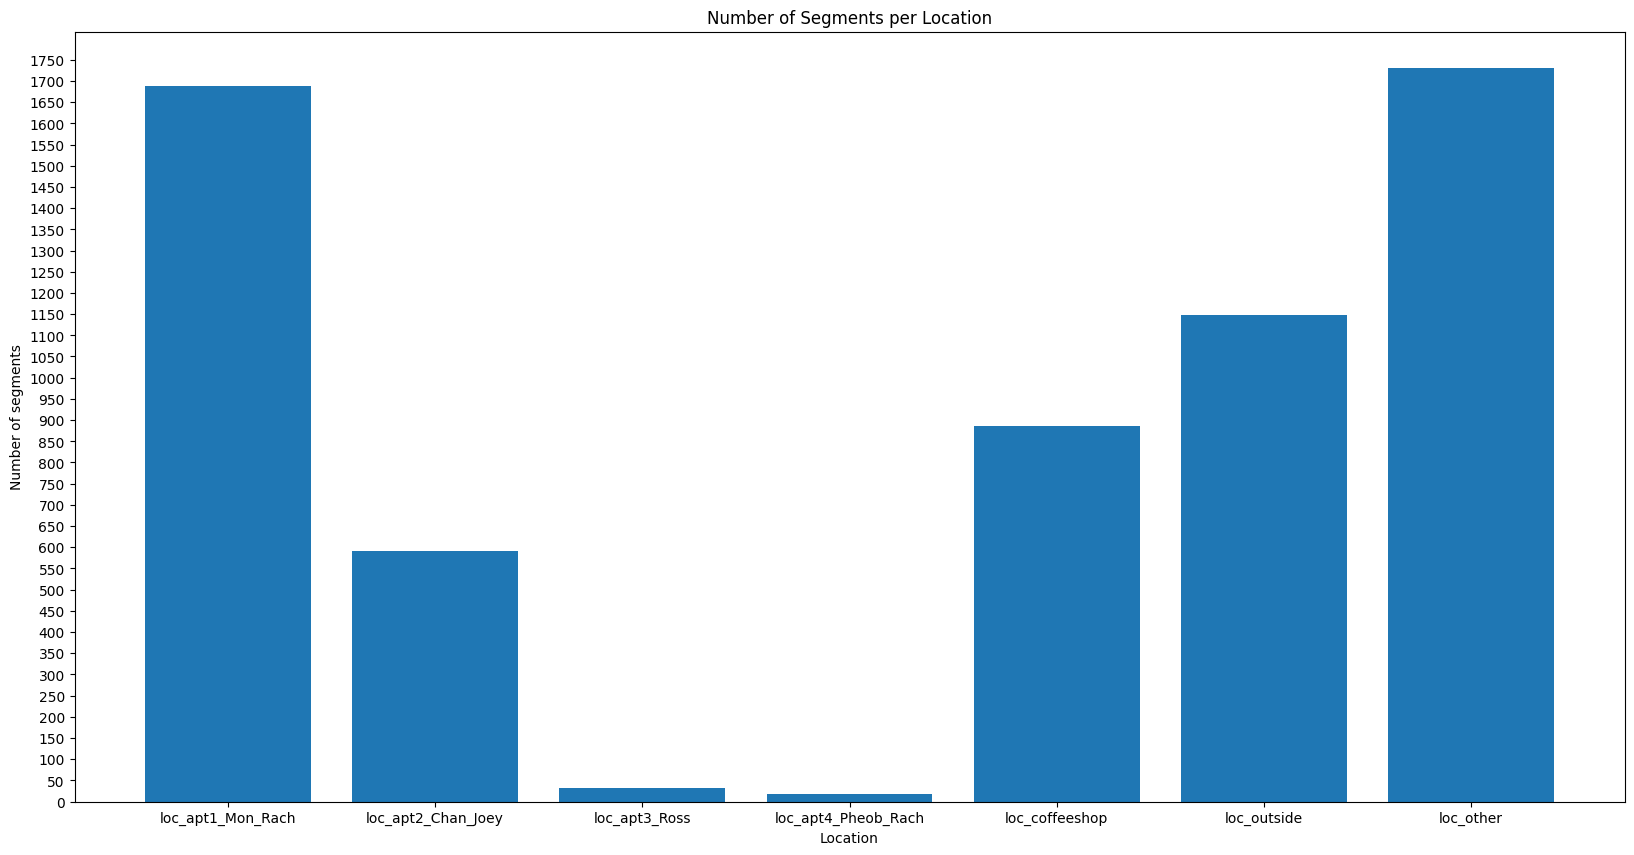

In [5]:
location_columns = ['loc_apt1_Mon_Rach', 'loc_apt2_Chan_Joey', 'loc_apt3_Ross', 'loc_apt4_Pheob_Rach',	'loc_coffeeshop', 'loc_outside', 'loc_other'] 
friends_pack.boolean_True_plotter(df,location_columns, 'Number of Segments per Location', 'Location', 'Number of segments')

# NUMBER OF SEGMENTS 🧩 PER ONBOUND/OFFBOUND 

A good amount of these segment transitions are due to location changes and time jumps!

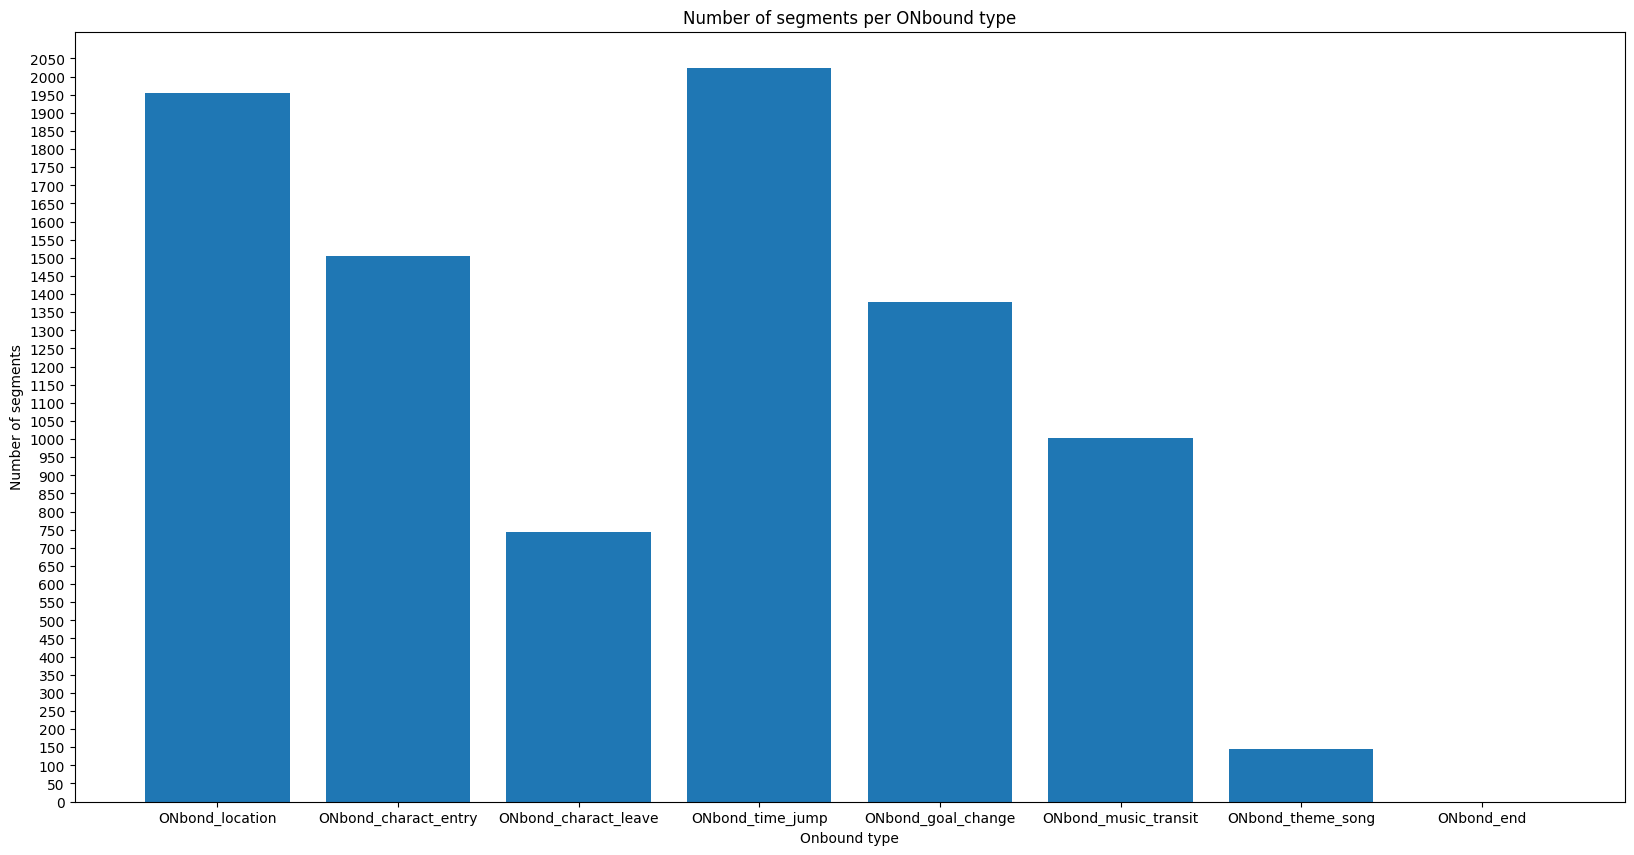

In [6]:
onbound_columns = ['ONbond_location', 'ONbond_charact_entry', 'ONbond_charact_leave', 'ONbond_time_jump', 'ONbond_goal_change', 'ONbond_music_transit',	'ONbond_theme_song','ONbond_end']
friends_pack.boolean_True_plotter(df,onbound_columns, 'Number of segments per ONbound type', 'Onbound type', 'Number of segments')

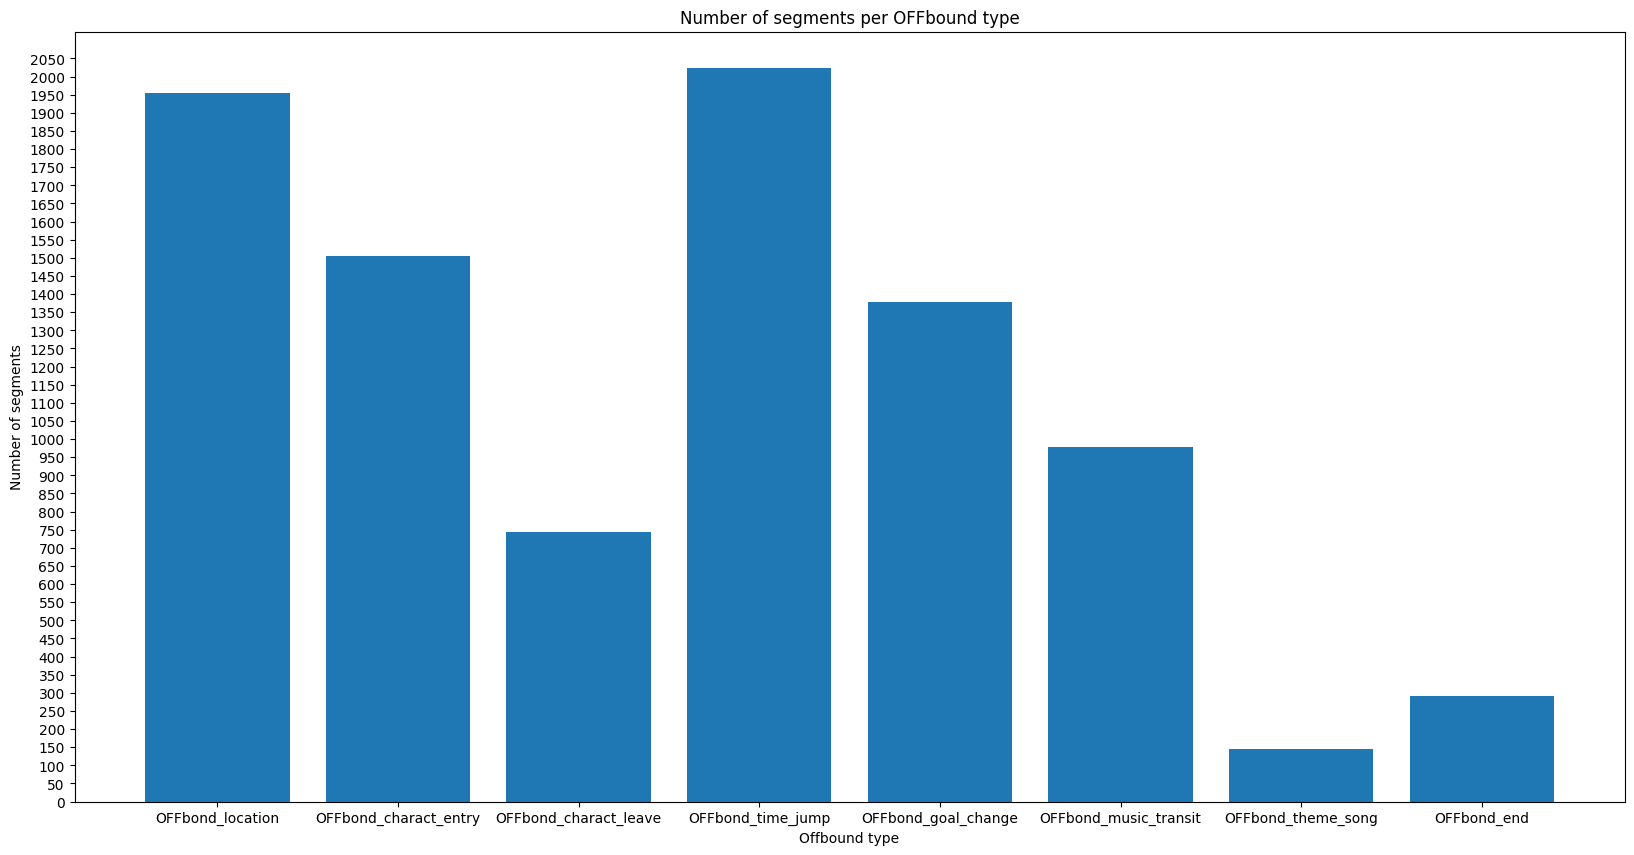

In [7]:
offbound_columns = ['OFFbond_location',	'OFFbond_charact_entry', 'OFFbond_charact_leave',	'OFFbond_time_jump', 'OFFbond_goal_change',	'OFFbond_music_transit',	'OFFbond_theme_song',	'OFFbond_end']
friends_pack.boolean_True_plotter(df,offbound_columns, 'Number of segments per OFFbound type', 'Offbound type', 'Number of segments')

This segment of code is to get the location of each segment

In [8]:
location_cols = [col for col in df.columns if col.startswith('loc_')]
id_vars = ['duration', 'season',] 
df_melted = df.melt(id_vars=['duration', 'season', 'global_segment'],
                    value_vars=location_cols,
                    var_name='location',
                    value_name='is_location')

df_true = df_melted[df_melted['is_location'] == True]



avg_duration = df_true.groupby('location')['duration'].mean().reset_index()




KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['season']"

# AVERAGE SEGMENT DURATION AND SEGMENT 🧩 DURATION 🕰️ BY LOCATION 📍🧛‍♂️

As we can see, the average lenght of segments in each locations is about the same except for outside. Feel free to explore the interactive plot to see the individual segments that might interest you.

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=avg_duration, x='location', y='duration', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Average Duration by Location')
plt.ylabel('Average Duration')
plt.xlabel('Location')
plt.tight_layout()
plt.show()

In [ ]:

import plotly.graph_objects as go

# Sort seasons
seasons = sorted(df_true['season'].unique())
fig = go.Figure()

# Add one violin plot per season (but only first season is visible by default)
for i, season in enumerate(seasons):
    filtered_df = df_true[df_true['season'] == season]

    fig.add_trace(go.Violin(
        y=filtered_df["duration"],
        x=filtered_df["location"],
        name=f"Season {season}",
        box_visible=True,
        meanline_visible=True,
        points="all",
        hovertext=filtered_df["global_segment"],
        visible=(i == 0),
        customdata=filtered_df[['global_segment', 'duration']].values,
            hovertemplate=(
                "location: %{x}<br>" +
                "Global segment: %{customdata[0]}<br>" +
                "Duration: %{customdata[1]} seconds<br>" +
                "<extra></extra>"  # hides the trace name in the tooltip
    )))

# Create dropdown buttons to toggle seasons
dropdown_buttons = [
    dict(
        label=f"Season {season}",
        method="update",
        args=[
            {"visible": [i == j for j in range(len(seasons))]},
            {"title": f"Segment Duration by Location – Season {season}"}
        ]
    )
    for i, season in enumerate(seasons)
]

# Update layout with dropdown and labels
fig.update_layout(
    updatemenus=[dict(
        buttons=dropdown_buttons,
        active=0,
        x=0.1,
        y=1.2,
        xanchor="left",
        yanchor="top"
    )],
    xaxis_title="Location",
    yaxis_title="Duration (seconds)",
    title=f"Segment Duration by Location – Season {seasons[0]}",
    width=1200,
    height=600
)

fig.show()


In [ ]:
ON_cols = [col for col in df.columns if col.startswith('ONbond_')]
id_vars2 = ['duration', 'season',] 
df_melted2 = df.melt(id_vars=['duration', 'season', 'global_segment'],
                    value_vars=ON_cols,
                    var_name='Onbond',
                    value_name='is_Onbond')

df_true2 = df_melted2[df_melted2['is_Onbond'] == True]



# SEGMENT 🧩 DURATION 🕰️ FOR ONBOUND/OFFBOUND TYPE

Here we see that segments that were from a music or transit theme song transtion don't last very long

In [ ]:
# Sort seasons
seasons = sorted(df_true2['season'].unique())
fig = go.Figure()

# Add one violin plot per season (but only first season is visible by default)
for i, season in enumerate(seasons):
    filtered_df2 = df_true2[df_true2['season'] == season]

    fig.add_trace(go.Violin(
        y=filtered_df2["duration"],
        x=filtered_df2["Onbond"],
        name=f"Season {season}",
        box_visible=True,
        meanline_visible=True,
        points="all",
        hovertext=filtered_df2["global_segment"],
        visible=(i == 0),
        customdata=filtered_df2[['global_segment', 'duration']].values,
            hovertemplate=(
                "Onbond: %{x}<br>" +
                "Global segment: %{customdata[0]}<br>" +
                "Duration: %{customdata[1]} seconds<br>" +
                "<extra></extra>"  # hides the trace name in the tooltip
    )))

# Create dropdown buttons to toggle seasons
dropdown_buttons = [
    dict(
        label=f"Season {season}",
        method="update",
        args=[
            {"visible": [i == j for j in range(len(seasons))]},
            {"title": f"Segment Duration by Onbound– Season {season}"}
        ]
    )
    for i, season in enumerate(seasons)
]

# Update layout with dropdown and labels
fig.update_layout(
    updatemenus=[dict(
        buttons=dropdown_buttons,
        active=0,
        x=0.1,
        y=1.2,
        xanchor="left",
        yanchor="top"
    )],
    xaxis_title="Onbound",
    yaxis_title="Duration (seconds)",
    title=f"Segment Duration by Onbound – Season {seasons[0]}",
    width=1200,
    height=600
)

fig.show()


# SEGMENT 🧩 DURATION 🕰️ 

Feel free to explore this scatter plot for every segments!

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Group your data by season
seasons = sorted(df['season'].unique())
fig = go.Figure()

# Create one trace per season, initially only show the first
for i, season in enumerate(seasons):
    season_df = df[df['season'] == season]
    visible = (i == 0)  # Only first season is visible by default

    fig.add_trace(go.Scatter(
        x=season_df["global_segment"],
        y=season_df["duration"],
        mode="markers",
        name=f"Season {season}",
        visible=visible,
        customdata=season_df[['global_segment', 'duration']].values,
            hovertemplate=(
                "location: %{x}<br>" +
                "Global segment: %{customdata[0]}<br>" +
                "Duration: %{customdata[1]} seconds<br>" +
                "<extra></extra>"  # hides the trace name in the tooltip
    )))

# Create dropdown buttons
dropdown_buttons = [
    dict(
        label=f"Season {season}",
        method="update",
        args=[
            {"visible": [i == j for j in range(len(seasons))]},
            {"title": f"Segment Duration – Season {season}"}
        ]
    )
    for i, season in enumerate(seasons)
]

# Add dropdown to layout
fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=dropdown_buttons,
        x=0.1,
        y=1.15,
        xanchor='left',
        yanchor='top'
    )],
    xaxis_title="Global Segment",
    yaxis_title="Duration (seconds)",
    title=f"Segment Duration – Season {seasons[0]}",
    width=1000,
    height=600
)


fig.show()